In [40]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_style("whitegrid")

## Load Dataset

In [41]:
DATA_PATH = Path("D:\\ARFI\Kuliah\Project\\HRSS_recommendation_system\\data\\raw")

standard_df = pd.read_csv(DATA_PATH / "HRSS_normal_standard.csv")
optimized_df = pd.read_csv(DATA_PATH / "HRSS_normal_optimized.csv")

**Why Anomalous Datasets Are Not Used in the Core Experiment**

Pada tahap utama project ini, dataset yang digunakan hanya:

- `HRSS_normal_standard.csv`
- `HRSS_normal_optimized.csv`

Sedangkan dataset:
- `HRSS_anomalous_standard.csv`
- `HRSS_anomalous_optimized.csv`

tidak digunakan pada core experiment.

Hal ini dilakukan karena fokus utama project adalah membangun:

**Industrial Operational Recommendation System**
untuk menganalisis dan mengenali:
- pola operasi efisien,
- perbedaan standard vs optimized operation,
- hubungan movement dan konsumsi energi,
- operational strategy yang lebih hemat energi.

---

**Fokus Utama Project**

Target utama machine learning pada project ini adalah:

- `standard operation`
- `optimized operation`

bukan:
- anomaly detection,
- failure detection,
- predictive maintenance.

Dengan demikian, model diharapkan mempelajari:
- operational efficiency behavior,
- movement synchronization,
- energy consumption pattern,
- efficient operational strategy.

---

**Alasan Tidak Menggunakan Dataset Anomaly pada Core Experiment**

1. **Anomaly bukan business objective utama**

Project ini berfokus pada:
- operational optimization,
- energy efficiency,
- recommendation strategy.

Bukan pada:
- mendeteksi kerusakan sistem,
- failure monitoring,
- anomaly classification.

---

2. **Anomaly dapat menjadi noise pada pembelajaran efficiency pattern**

Data anomaly dapat merepresentasikan:
- abnormal movement,
- sensor instability,
- failure behavior,
- operational interruption.

Kondisi tersebut belum tentu berkaitan langsung dengan:
- efficient operation,
- optimized movement behavior.

Jika anomaly dicampurkan pada core experiment, model berpotensi:
- mempelajari failure pattern,
- bukan mempelajari efficiency pattern.

---

3. **Membuat problem framing lebih bersih dan terfokus**

Dengan hanya menggunakan kondisi operasi normal, model dapat fokus mempelajari:

- standard operation behavior,
- optimized operation behavior,

dalam kondisi operasional yang valid dan stabil.

Hal ini membuat:
- interpretasi model lebih jelas,
- feature engineering lebih meaningful,
- recommendation system lebih explainable.

---

4. **Mengurangi risiko distribution bias dan feature distortion**

Anomalous telemetry dapat menghasilkan:
- extreme spike,
- abnormal power usage,
- unusual movement behavior.

Jika langsung dicampurkan, distribusi feature dapat menjadi bias dan menyulitkan model dalam mengenali pola efisiensi operasional yang sebenarnya.

---

**Posisi Dataset Anomaly dalam Project**

Meskipun tidak digunakan pada core experiment, dataset anomaly tetap memiliki nilai penting sebagai:
- robustness testing,
- future enhancement,
- anomaly-aware operational analysis,
- predictive maintenance extension.

Dataset anomaly dapat digunakan pada tahap lanjutan untuk menguji:
- stabilitas model,
- ketahanan recommendation system,
- performa model pada kondisi abnormal.

---

Dengan pendekatan ini, core experiment tetap fokus pada:
- operational intelligence,
- energy optimization,
- recommendation strategy,

sesuai objective utama project industrial telemetry analytics ini.

In [42]:
# ============================================================
# DATASET SHAPE
# ============================================================

print("Standard Dataset Shape :", standard_df.shape)
print("Optimized Dataset Shape:", optimized_df.shape)

Standard Dataset Shape : (25907, 20)
Optimized Dataset Shape: (21329, 20)


In [43]:
# ============================================================
# PREVIEW DATASET
# ============================================================

standard_df.head()

,Timestamp,Labels,I_w_BLO_Weg,O_w_BLO_power,O_w_BLO_voltage,I_w_BHL_Weg,O_w_BHL_power,O_w_BHL_voltage,I_w_BHR_Weg,O_w_BHR_power,O_w_BHR_voltage,I_w_BRU_Weg,O_w_BRU_power,O_w_BRU_voltage,I_w_HR_Weg,O_w_HR_power,O_w_HR_voltage,I_w_HL_Weg,O_w_HL_power,O_w_HL_voltage
0,0.00,0,-107,0,0,0,0,0,-1268,0,0,-26,84,11,0,7168,26,0,7720,24
1,0.05,0,-107,0,0,0,0,0,-1268,0,0,-26,84,11,0,7168,26,0,7720,24
2,0.15,0,-107,0,0,0,0,0,-1268,0,0,-26,84,11,0,7168,26,0,7720,24
3,0.21,0,-107,0,0,0,0,0,-1268,0,0,29,21725,54,0,6726,26,0,10756,26
4,0.26,0,-107,0,0,0,0,0,-1268,0,0,29,21725,54,0,6726,26,0,10756,26


In [44]:
# ============================================================
# COLUMN STRUCTURE
# ============================================================

standard_df.columns

Index(['Timestamp', 'Labels', 'I_w_BLO_Weg', 'O_w_BLO_power',
       'O_w_BLO_voltage', 'I_w_BHL_Weg', 'O_w_BHL_power', 'O_w_BHL_voltage',
       'I_w_BHR_Weg', 'O_w_BHR_power', 'O_w_BHR_voltage', 'I_w_BRU_Weg',
       'O_w_BRU_power', 'O_w_BRU_voltage', 'I_w_HR_Weg', 'O_w_HR_power',
       'O_w_HR_voltage', 'I_w_HL_Weg', 'O_w_HL_power', 'O_w_HL_voltage'],
      dtype='object')

In [45]:
# ============================================================
# DATA TYPES
# ============================================================

standard_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25907 entries, 0 to 25906
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Timestamp        25907 non-null  float64
 1   Labels           25907 non-null  int64  
 2   I_w_BLO_Weg      25907 non-null  int64  
 3   O_w_BLO_power    25907 non-null  int64  
 4   O_w_BLO_voltage  25907 non-null  int64  
 5   I_w_BHL_Weg      25907 non-null  int64  
 6   O_w_BHL_power    25907 non-null  int64  
 7   O_w_BHL_voltage  25907 non-null  int64  
 8   I_w_BHR_Weg      25907 non-null  int64  
 9   O_w_BHR_power    25907 non-null  int64  
 10  O_w_BHR_voltage  25907 non-null  int64  
 11  I_w_BRU_Weg      25907 non-null  int64  
 12  O_w_BRU_power    25907 non-null  int64  
 13  O_w_BRU_voltage  25907 non-null  int64  
 14  I_w_HR_Weg       25907 non-null  int64  
 15  O_w_HR_power     25907 non-null  int64  
 16  O_w_HR_voltage   25907 non-null  int64  
 17  I_w_HL_Weg  

In [46]:
# ============================================================
# STATISTICAL SUMMARY
# ============================================================

standard_df.describe()

,Timestamp,Labels,I_w_BLO_Weg,O_w_BLO_power,O_w_BLO_voltage,I_w_BHL_Weg,O_w_BHL_power,O_w_BHL_voltage,I_w_BHR_Weg,O_w_BHR_power,O_w_BHR_voltage,I_w_BRU_Weg,O_w_BRU_power,O_w_BRU_voltage,I_w_HR_Weg,O_w_HR_power,O_w_HR_voltage,I_w_HL_Weg,O_w_HL_power,O_w_HL_voltage
count,25907.00,25907.00,25907.00,25907.00,25907.00,25907.00,25907.00,25907.00,25907.00,25907.00,25907.00,25907.00,25907.00,25907.00,25907.00,25907.00,25907.00,25907.00,25907.00,25907.00
mean,7.59,0.00,44.00,4923.84,12.83,56.80,6996.66,18.51,42.24,6196.42,17.94,429.01,5116.82,13.17,-411.70,11341.64,50.29,-411.70,13153.06,50.11
std,4.40,0.00,193.11,9007.85,22.51,490.79,10208.37,25.37,583.64,9099.57,25.00,302.90,9403.64,23.09,406.54,6862.37,84.82,406.55,7945.88,84.40
min,0.00,0.00,-110.00,0.00,0.00,-548.00,0.00,0.00,-1322.00,0.00,0.00,-628.00,0.00,0.00,-833.00,0.00,0.00,-833.00,0.00,0.00
25%,3.77,0.00,-106.00,0.00,0.00,-322.00,0.00,0.00,-340.00,0.00,0.00,572.00,0.00,0.00,-833.00,6830.00,26.00,-833.00,7408.00,24.00
50%,7.58,0.00,8.00,0.00,0.00,0.00,54.00,1.00,391.00,0.00,0.00,573.00,0.00,0.00,-324.00,9300.00,26.00,-322.00,11094.00,26.00
75%,11.41,0.00,12.00,1218.00,11.00,416.00,19827.00,55.00,477.00,17524.00,54.00,574.00,270.00,3.00,0.00,14212.00,29.00,0.00,18370.00,29.00
max,15.44,0.00,619.00,32132.00,61.00,880.00,32508.00,66.00,479.00,32536.00,65.00,604.00,32674.00,62.00,0.00,32752.00,543.00,0.00,32761.00,532.00


In [47]:
# ============================================================
# LABEL VALIDATION
# ============================================================

print("Standard Labels")
print(standard_df["Labels"].value_counts())

print("\nOptimized Labels")
print(optimized_df["Labels"].value_counts())

Standard Labels
Labels
0    25907
Name: count, dtype: int64

Optimized Labels
Labels
0    21329
Name: count, dtype: int64


In [48]:
# ============================================================
# DROP LABEL COLUMN
# ============================================================

standard_df.drop(columns=["Labels"], inplace=True)
optimized_df.drop(columns=["Labels"], inplace=True)

In [49]:
# ============================================================
# ADD TARGET LABEL
# ============================================================

standard_df["operation_type"] = 0
optimized_df["operation_type"] = 1

In [50]:
# ============================================================
# ADD OPERATION NAME
# ============================================================

standard_df["operation_name"] = "standard"
optimized_df["operation_name"] = "optimized"

In [51]:
# ============================================================
# DATA INTEGRATION
# ============================================================

df = pd.concat([
    standard_df,
    optimized_df
], ignore_index=True)

print("Integrated Dataset Shape:")
print(df.shape)

Integrated Dataset Shape:
(47236, 21)


In [52]:
# ============================================================
# MISSING VALUE CHECK
# ============================================================

missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [53]:
# ============================================================
# DUPLICATE CHECK
# ============================================================

duplicates = df.duplicated().sum()

print("Duplicated Rows:", duplicates)

# ============================================================
# REMOVE DUPLICATES
# ============================================================

if duplicates > 0:
    df = df.drop_duplicates()

print("Dataset Shape After Duplicate Removal:")
print(df.shape)

Duplicated Rows: 338
Dataset Shape After Duplicate Removal:
(46898, 21)


In [54]:
df.describe()

,Timestamp,I_w_BLO_Weg,O_w_BLO_power,O_w_BLO_voltage,I_w_BHL_Weg,O_w_BHL_power,O_w_BHL_voltage,I_w_BHR_Weg,O_w_BHR_power,O_w_BHR_voltage,I_w_BRU_Weg,O_w_BRU_power,O_w_BRU_voltage,I_w_HR_Weg,O_w_HR_power,O_w_HR_voltage,I_w_HL_Weg,O_w_HL_power,O_w_HL_voltage,operation_type
count,46898.00,46898.00,46898.00,46898.00,46898.00,46898.00,46898.00,46898.00,46898.00,46898.00,46898.00,46898.00,46898.00,46898.00,46898.00,46898.00,46898.00,46898.00,46898.00,46898.00
mean,6.85,41.74,5148.89,13.68,56.32,5715.95,19.83,19.45,5430.47,21.27,396.84,5742.40,14.97,-408.57,11425.97,51.52,-408.57,12862.57,51.33,0.45
std,4.09,181.92,8739.82,22.21,535.27,9118.32,30.22,700.24,8371.48,30.71,324.72,9366.17,23.33,398.83,6704.06,73.96,398.83,7703.48,73.71,0.50
min,0.00,-110.00,0.00,0.00,-748.00,0.00,0.00,-1322.00,0.00,0.00,-855.00,0.00,0.00,-833.00,0.00,0.00,-833.00,0.00,0.00,0.00
25%,3.36,-106.00,0.00,0.00,-537.00,0.00,0.00,-690.25,0.00,0.00,385.00,0.00,0.00,-833.00,6908.00,26.00,-833.00,7096.00,24.00,0.00
50%,6.75,8.00,0.00,0.00,0.00,41.00,1.00,385.00,2.00,1.00,566.00,0.00,0.00,-332.00,9638.00,26.00,-330.00,11188.00,26.00,0.00
75%,10.15,27.00,10982.00,35.00,522.00,12864.00,51.00,478.00,12916.00,51.00,573.00,16497.00,47.00,0.00,14293.00,29.00,0.00,16735.00,29.00,1.00
max,15.44,619.00,32132.00,61.00,995.00,32648.00,105.00,784.00,32752.00,103.00,604.00,32674.00,62.00,0.00,32760.00,543.00,0.00,32761.00,532.00,1.00


In [55]:
df.shape

(46898, 21)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46898 entries, 0 to 47235
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Timestamp        46898 non-null  float64
 1   I_w_BLO_Weg      46898 non-null  int64  
 2   O_w_BLO_power    46898 non-null  int64  
 3   O_w_BLO_voltage  46898 non-null  int64  
 4   I_w_BHL_Weg      46898 non-null  int64  
 5   O_w_BHL_power    46898 non-null  int64  
 6   O_w_BHL_voltage  46898 non-null  int64  
 7   I_w_BHR_Weg      46898 non-null  int64  
 8   O_w_BHR_power    46898 non-null  int64  
 9   O_w_BHR_voltage  46898 non-null  int64  
 10  I_w_BRU_Weg      46898 non-null  int64  
 11  O_w_BRU_power    46898 non-null  int64  
 12  O_w_BRU_voltage  46898 non-null  int64  
 13  I_w_HR_Weg       46898 non-null  int64  
 14  O_w_HR_power     46898 non-null  int64  
 15  O_w_HR_voltage   46898 non-null  int64  
 16  I_w_HL_Weg       46898 non-null  int64  
 17  O_w_HL_power     

### Dataset Description

**Dataset Structure Overview**

Dataset terdiri dari telemetry sensor industri dari High Rack Storage System (HRSS) yang merekam aktivitas conveyor dan rail system secara time-series.

Dataset yang digunakan pada project ini merupakan hasil integrasi dari:
- HRSS_normal_standard.csv
- HRSS_normal_optimized.csv

Dataset memiliki (setelah drop duplikat):
- 46,898 baris data,
- 21 kolom,
- mayoritas fitur numerik,
- tanpa missing value.

---

**General Information**

| Property | Value |
|---|---|
| Total Rows | 46,898|
| Total Columns | 21 |
| Data Type | Numerical Industrial Telemetry Data |
| Memory Usage | ~7.9 MB |

---

**Column Categories**

Secara umum, fitur dalam dataset dibagi menjadi beberapa kelompok utama:

| Category | Description |
|---|---|
| Timestamp | Operational timestamp in seconds |
| Weg | Movement distance sensor |
| Power | Electrical power measurement |
| Voltage | Electrical voltage measurement |
| Operation Type | Binary operational class |
| Operation Name | Operational category label |

---

**Component Description**

Sistem HRSS terdiri dari beberapa komponen conveyor dan rail:

| Component | Description |
|---|---|
| BLO | Top Left Conveyor |
| BHL | Middle Left Conveyor |
| BHR | Middle Right Conveyor |
| BRU | Bottom Right Conveyor |
| HL | Left Rail |
| HR | Right Rail |

---

**Detailed Column Description**

| Column | Type | Description |
|---|---|---|
| Timestamp | float64 | Operational timestamp in seconds |
| operation_type | int64 | Binary operational class (0 = standard, 1 = optimized) |
| operation_name | object | Operational category name |

---

**Movement Distance Features (Weg)**

Fitur Weg digunakan untuk merepresentasikan movement distance yang dihasilkan oleh conveyor dan rail system selama operasi industri berlangsung.

| Column | Description |
|---|---|
| I_w_BLO_Weg | Movement distance conveyor BLO |
| I_w_BHL_Weg | Movement distance conveyor BHL |
| I_w_BHR_Weg | Movement distance conveyor BHR |
| I_w_BRU_Weg | Movement distance conveyor BRU |
| I_w_HR_Weg | Movement distance right rail |
| I_w_HL_Weg | Movement distance left rail |

---

**Power Features**

Fitur power merepresentasikan electrical power measurement dari masing-masing komponen sistem industri.

| Column | Description |
|---|---|
| O_w_BLO_power | Electrical power conveyor BLO |
| O_w_BHL_power | Electrical power conveyor BHL |
| O_w_BHR_power | Electrical power conveyor BHR |
| O_w_BRU_power | Electrical power conveyor BRU |
| O_w_HR_power | Electrical power right rail |
| O_w_HL_power | Electrical power left rail |

---

**Voltage Features**

Fitur voltage merepresentasikan electrical voltage measurement pada masing-masing komponen sistem industri.

| Column | Description |
|---|---|
| O_w_BLO_voltage | Electrical voltage conveyor BLO |
| O_w_BHL_voltage | Electrical voltage conveyor BHL |
| O_w_BHR_voltage | Electrical voltage conveyor BHR |
| O_w_BRU_voltage | Electrical voltage conveyor BRU |
| O_w_HR_voltage | Electrical voltage right rail |
| O_w_HL_voltage | Electrical voltage left rail |

---

**Target Variable Description**

Project ini menggunakan target klasifikasi:

| Target | Meaning |
|---|---|
| 0 | Standard Operation |
| 1 | Optimized Operation |

Target dibentuk berdasarkan asal dataset:
- HRSS_normal_standard.csv → standard operation
- HRSS_normal_optimized.csv → optimized operation

Kolom `operation_name` digunakan sebagai representasi kategorikal yang lebih mudah dibaca untuk interpretasi hasil analisis dan visualisasi.

---

**Data Characteristics**

Karakteristik utama dataset:

- Mayoritas fitur bersifat numerik.
- Dataset tidak memiliki missing value.
- Dataset merepresentasikan industrial telemetry time-series system.
- Setiap row merepresentasikan snapshot kondisi operasional sistem pada waktu tertentu.
- Dataset memiliki pola telemetry yang bersifat event-driven dan sparse.
- Beberapa sensor menunjukkan idle condition dengan nilai 0 pada sebagian besar timestamp.
- Dataset digunakan untuk menganalisis hubungan antara:
  - movement distance,
  - konsumsi energi,
  - operational efficiency.

---

**Machine Learning Perspective**

Project ini menggunakan pendekatan:

Supervised Machine Learning → Binary Classification

dengan tujuan utama:
- mengenali pola operasi optimized,
- membedakan standard dan optimized operation,
- memahami hubungan movement dan konsumsi energi,
- menghasilkan recommendation strategy untuk operational movement yang lebih efisien.

Project ini bukan recommendation system tradisional seperti collaborative filtering atau product recommendation system, melainkan:

Classification-Based Industrial Operational Recommendation System

yang dibangun menggunakan telemetry analytics dan operational behavior modeling.

<Axes: xlabel='operation_name'>

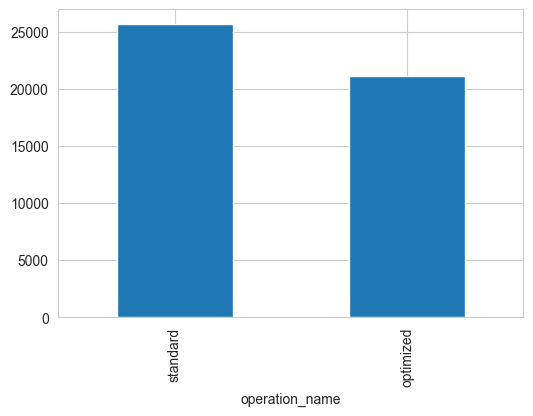

In [57]:
# ============================================================
# TARGET DISTRIBUTION
# ============================================================

df["operation_name"].value_counts().plot(kind="bar", figsize=(6,4))

In [58]:
# ============================================================
# TARGET DISTRIBUTION
# ============================================================

target_dist = (
    df["operation_name"]
    .value_counts()
    .rename_axis("operation_name")
    .reset_index(name="count")
)

target_dist["percentage"] = (
    target_dist["count"] / target_dist["count"].sum() * 100
).round(2)

target_dist

,operation_name,count,percentage
0,standard,25724,54.85
1,optimized,21174,45.15


In [59]:
# ============================================================
# FEATURE GROUPING
# ============================================================

weg_cols = [
    col for col in df.columns
    if "Weg" in col
]

power_cols = [
    col for col in df.columns
    if "power" in col
]

voltage_cols = [
    col for col in df.columns
    if "voltage" in col
]

print("Movement Features:")
print(weg_cols)

print("\nPower Features:")
print(power_cols)

print("\nVoltage Features:")
print(voltage_cols)

Movement Features:
['I_w_BLO_Weg', 'I_w_BHL_Weg', 'I_w_BHR_Weg', 'I_w_BRU_Weg', 'I_w_HR_Weg', 'I_w_HL_Weg']

Power Features:
['O_w_BLO_power', 'O_w_BHL_power', 'O_w_BHR_power', 'O_w_BRU_power', 'O_w_HR_power', 'O_w_HL_power']

Voltage Features:
['O_w_BLO_voltage', 'O_w_BHL_voltage', 'O_w_BHR_voltage', 'O_w_BRU_voltage', 'O_w_HR_voltage', 'O_w_HL_voltage']


In [60]:
# ============================================================
# CONSTANT FEATURE CHECK
# ============================================================

unique_counts = df.nunique().sort_values()

unique_counts

operation_name         2
operation_type         2
O_w_BLO_voltage       51
O_w_BRU_voltage       52
O_w_BHR_voltage       85
O_w_BHL_voltage       87
O_w_HL_voltage       301
O_w_HR_voltage       304
I_w_BLO_Weg          704
I_w_HR_Weg           714
I_w_HL_Weg           721
I_w_BRU_Weg         1144
I_w_BHL_Weg         1486
O_w_BRU_power       1684
I_w_BHR_Weg         1703
O_w_BLO_power       1888
O_w_BHL_power       2283
O_w_BHR_power       2466
O_w_HL_power        2802
O_w_HR_power        2921
Timestamp          20259
dtype: int64

In [61]:
# ============================================================
# TIMESTAMP UNDERSTANDING
# ============================================================

print("Timestamp dtype:", df["Timestamp"].dtype)
print("Timestamp min:", df["Timestamp"].min())
print("Timestamp max:", df["Timestamp"].max())
print("Timestamp unique count:", df["Timestamp"].nunique())
print("Monotonic increasing:", df["Timestamp"].is_monotonic_increasing)

print("\nFirst 10 Timestamp values:")
print(df["Timestamp"].head(10).tolist())

print("\nLast 10 Timestamp values:")
print(df["Timestamp"].tail(10).tolist())

# Optional: if you want to inspect sampling interval behavior,
# uncomment the line below.
# print(df["Timestamp"].diff().head(20))

Timestamp dtype: float64
Timestamp min: 0.0
Timestamp max: 15.4379959106445
Timestamp unique count: 20259
Monotonic increasing: False

First 10 Timestamp values:
[0.0, 0.0459976196289063, 0.1510009765625, 0.206001281738281, 0.263999938964844, 0.317001342773438, 0.385002136230469, 0.431999206542969, 0.534996032714844, 0.590995788574219]

Last 10 Timestamp values:
[11.3679962158203, 11.4229965209961, 11.4679946899414, 11.5279998779297, 11.5929946899414, 11.6349945068359, 11.7519989013672, 11.7959976196289, 11.8839950561523, 11.931999206543]


## EDA

### Power

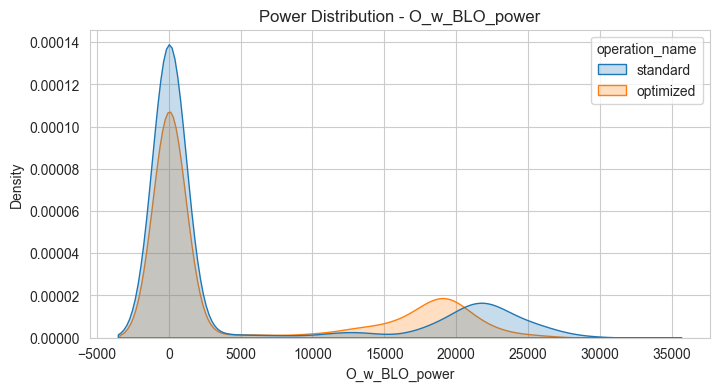

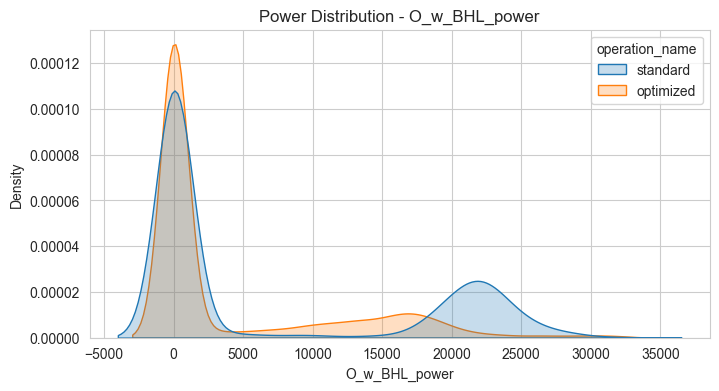

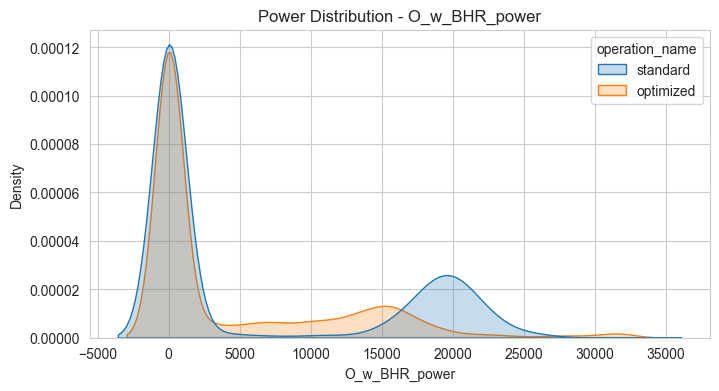

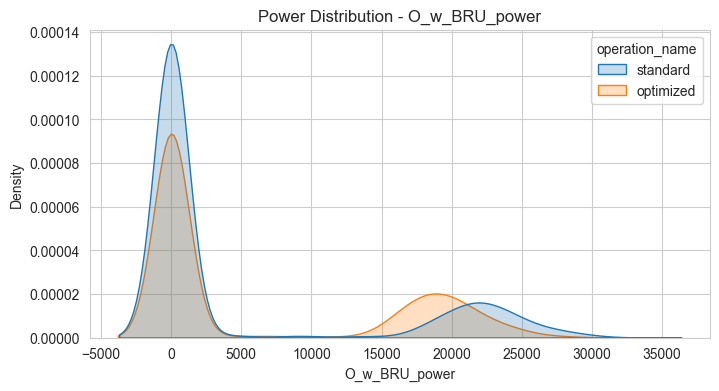

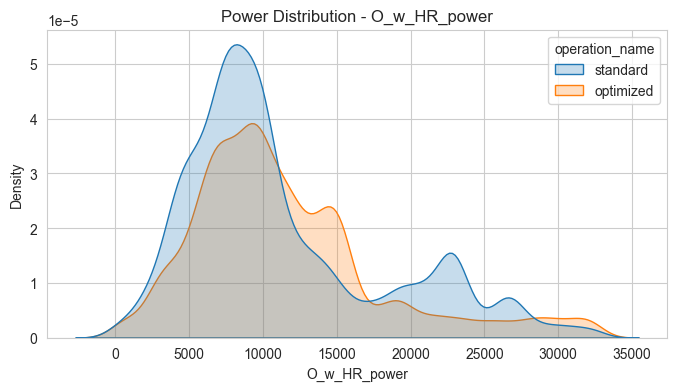

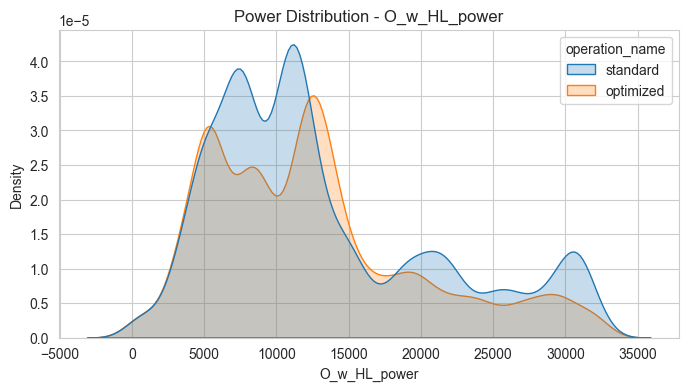

In [62]:
# ============================================================
# POWER DISTRIBUTION ANALYSIS
# ============================================================

for col in power_cols:

    plt.figure(figsize=(8,4))

    sns.kdeplot(
        data=df,
        x=col,
        hue="operation_name",
        fill=True
    )

    plt.title(f"Power Distribution - {col}")

    plt.show()

In [63]:
# ============================================================
# POWER COMPARISON
# ============================================================

power_comparison = df.groupby("operation_name")[power_cols].mean()

power_comparison

,O_w_BLO_power,O_w_BHL_power,O_w_BHR_power,O_w_BRU_power,O_w_HR_power,O_w_HL_power
operation_name,,,,,,
optimized,5429.38,4160.04,4490.63,6506.19,11519.88,12511.53
standard,4918.01,6996.65,6204.08,5113.72,11348.67,13151.53


<Axes: xlabel='operation_name'>

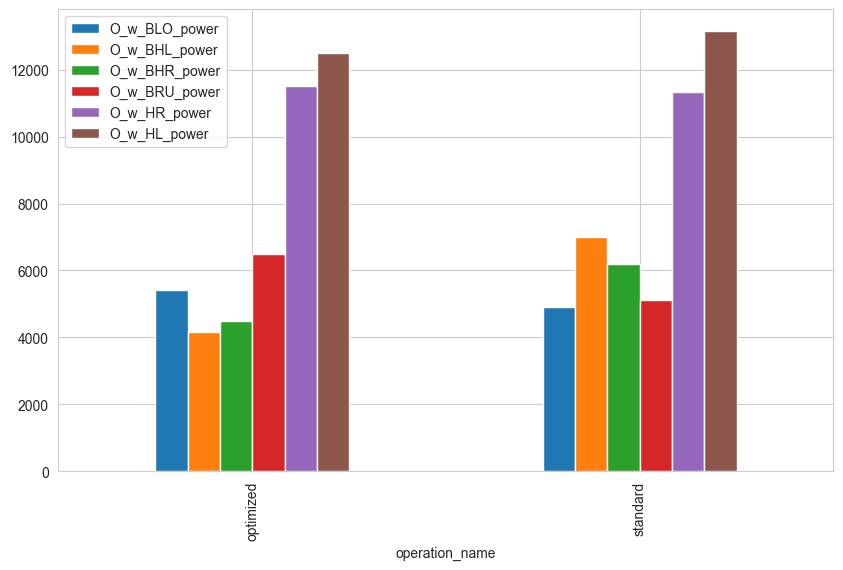

In [64]:
# ============================================================
# POWER COMPARISON
# ============================================================

power_comparison = df.groupby("operation_name")[power_cols].mean()

power_comparison.plot(kind="bar", figsize=(10,6))

### Movement

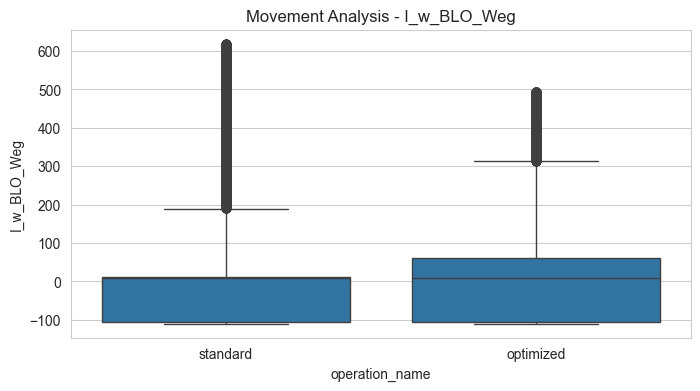

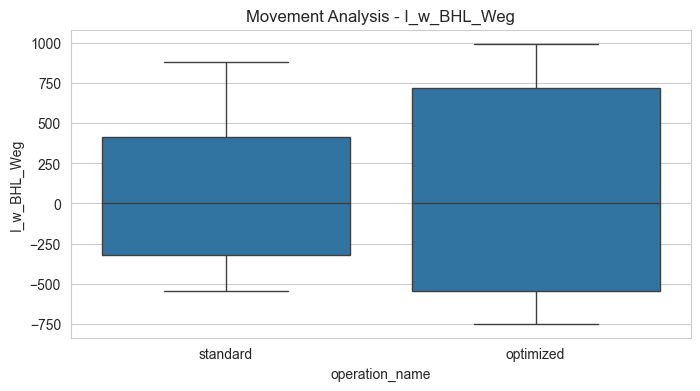

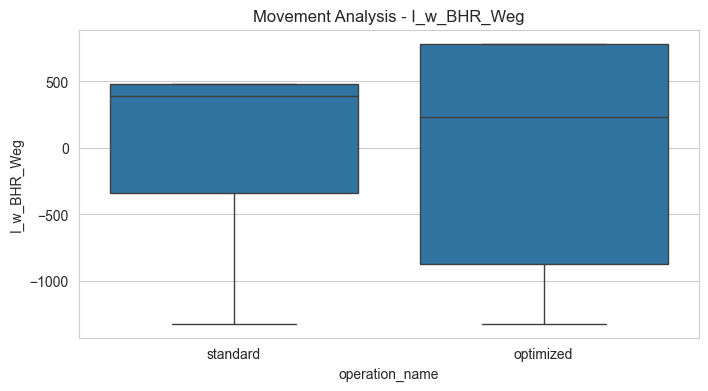

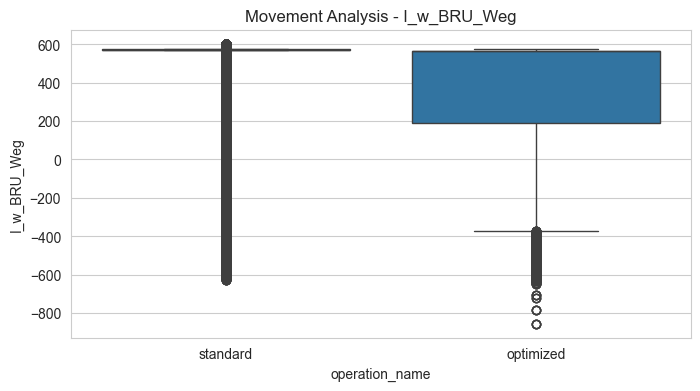

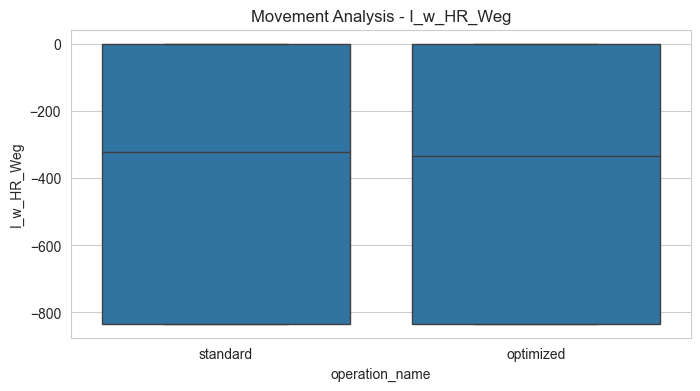

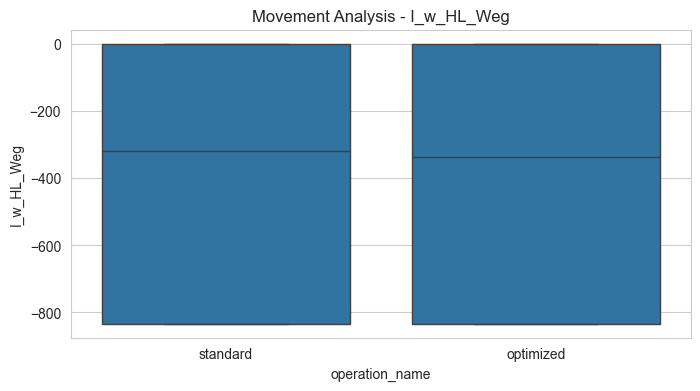

In [65]:
# ============================================================
# MOVEMENT ANALYSIS
# ============================================================

for col in weg_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        data=df,
        x="operation_name",
        y=col
    )

    plt.title(f"Movement Analysis - {col}")

    plt.show()

In [66]:
# ============================================================
# MOVEMENT COMPARISON
# ============================================================

movement_comparison = df.groupby("operation_name")[weg_cols].mean()

movement_comparison

,I_w_BLO_Weg,I_w_BHL_Weg,I_w_BHR_Weg,I_w_BRU_Weg,I_w_HR_Weg,I_w_HL_Weg
operation_name,,,,,,
optimized,39.15,56.29,-8.23,357.72,-404.97,-404.97
standard,43.87,56.35,42.23,429.05,-411.54,-411.53


<Axes: xlabel='operation_name'>

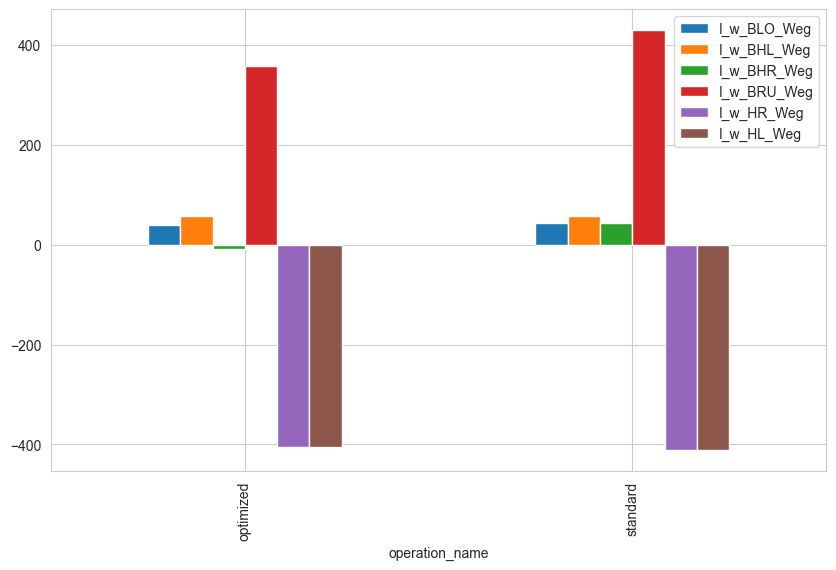

In [67]:
# ============================================================
# MOVEMENT COMPARISON
# ============================================================

movement_comparison = df.groupby("operation_name")[weg_cols].mean()

movement_comparison.plot(kind="bar", figsize=(10,6))    

### Voltage

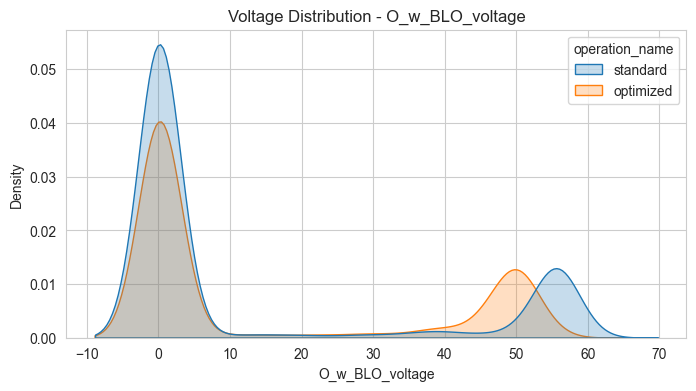

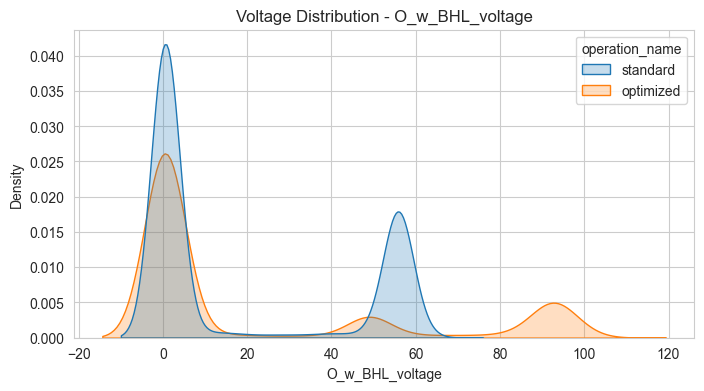

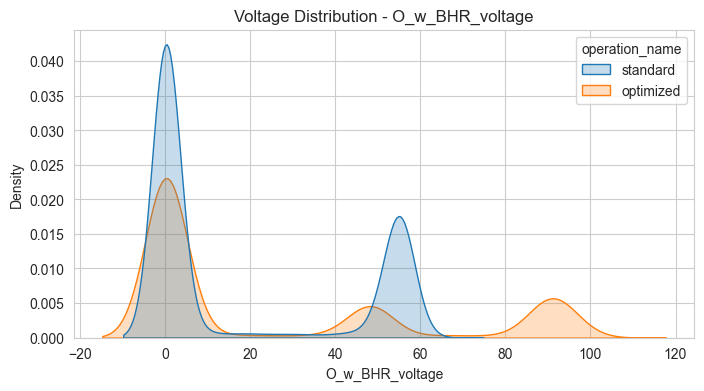

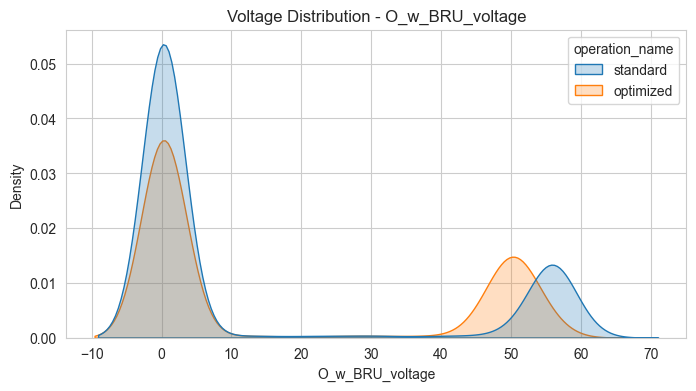

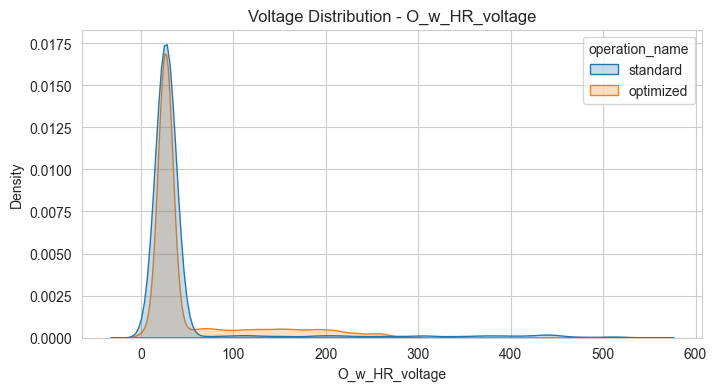

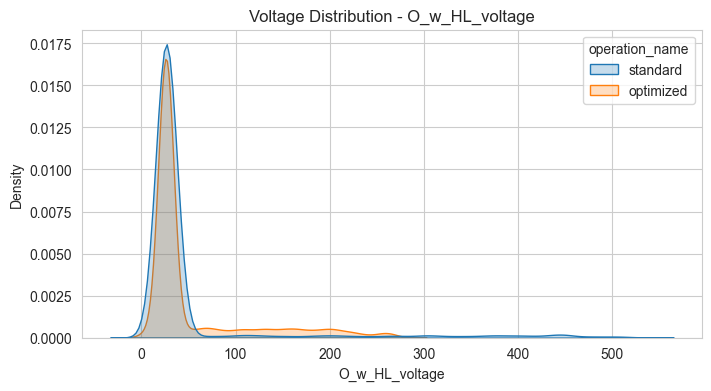

In [68]:
# ============================================================
# VOLTAGE ANALYSIS
# ============================================================

for col in voltage_cols:

    plt.figure(figsize=(8,4))

    sns.kdeplot(
        data=df,
        x=col,
        hue="operation_name",
        fill=True
    )

    plt.title(f"Voltage Distribution - {col}")

    plt.show()

In [69]:
# ============================================================
# VOLTAGE COMPARISON
# ============================================================

voltage_comparison = df.groupby("operation_name")[voltage_cols].mean()

voltage_comparison

,O_w_BLO_voltage,O_w_BHL_voltage,O_w_BHR_voltage,O_w_BRU_voltage,O_w_HR_voltage,O_w_HL_voltage
operation_name,,,,,,
optimized,14.74,21.43,25.30,17.17,52.97,52.79
standard,12.81,18.51,17.96,13.16,50.32,50.14


<Axes: xlabel='operation_name'>

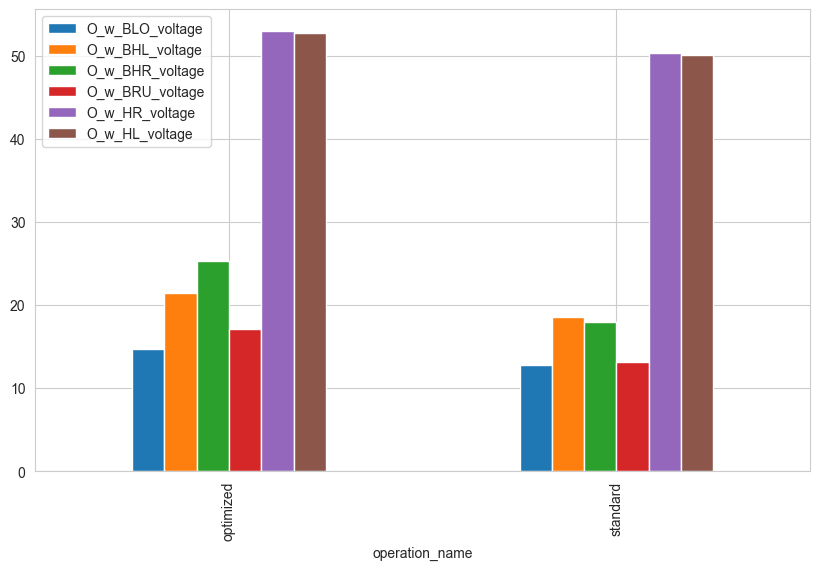

In [70]:
# ============================================================
# VOLTAGE COMPARISON
# ============================================================

voltage_comparison = df.groupby("operation_name")[voltage_cols].mean()

voltage_comparison.plot(kind="bar", figsize=(10,6))

### Outlier

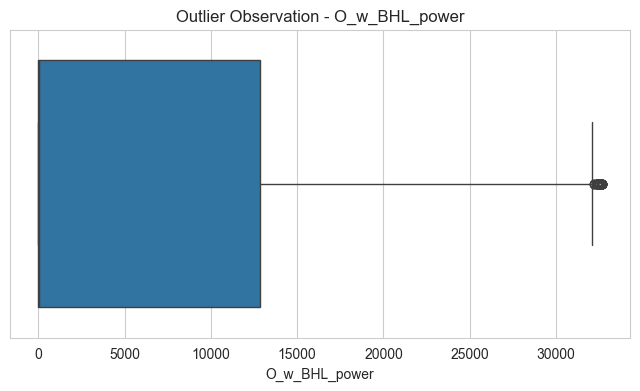

In [71]:
# ============================================================
# OUTLIER OBSERVATION
# ============================================================

plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["O_w_BHL_power"]
)

plt.title("Outlier Observation - O_w_BHL_power")

plt.show()

### Correlation

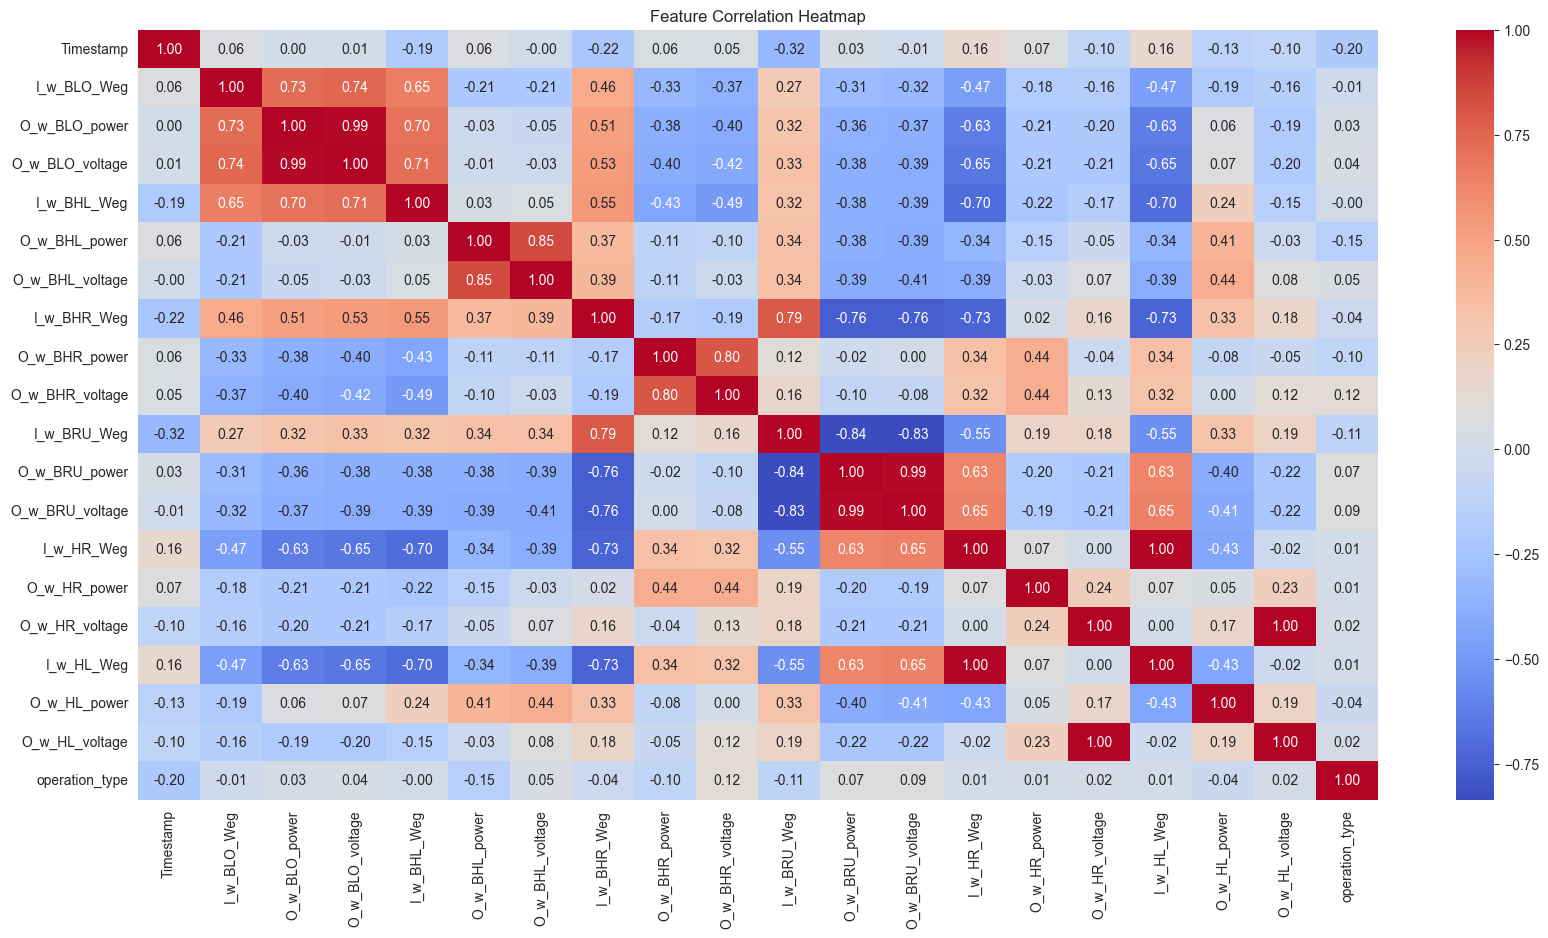

In [72]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

corr = df.corr(numeric_only=True)

plt.figure(figsize=(20,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

## Save Dataset

In [73]:
# ============================================================
# SAVE PROCESSED DATASET (ORIGINAL)
# ============================================================

import os
os.makedirs("../data/processed", exist_ok=True)

df.to_csv("../data/processed/hrss_clean_integrated_original_columns.csv", index=False)
print("Original dataset saved!")


Original dataset saved!


In [74]:
df.duplicated().sum()

0

In [75]:
df.isna().sum()

Timestamp          0
I_w_BLO_Weg        0
O_w_BLO_power      0
O_w_BLO_voltage    0
I_w_BHL_Weg        0
O_w_BHL_power      0
O_w_BHL_voltage    0
I_w_BHR_Weg        0
O_w_BHR_power      0
O_w_BHR_voltage    0
I_w_BRU_Weg        0
O_w_BRU_power      0
O_w_BRU_voltage    0
I_w_HR_Weg         0
O_w_HR_power       0
O_w_HR_voltage     0
I_w_HL_Weg         0
O_w_HL_power       0
O_w_HL_voltage     0
operation_type     0
operation_name     0
dtype: int64